# 📊 회귀분석 평가 지표 요약 (Regression Metrics Summary)

## 1. 주요 오차 기반 지표

### 📌 MSE (Mean Squared Error)
- **정의**: 예측값과 실제값의 차이를 제곱한 값의 평균
- **수식**: $MSE = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2$
- **특징**:
  - 큰 오차에 더 큰 패널티 부여 (제곱 효과)
  - 이상치(outlier)에 민감
  - 단위가 원래 타겟의 제곱 단위
- **해석**: 값이 작을수록 좋음

### 📌 RMSE (Root Mean Squared Error)
- **정의**: MSE의 제곱근
- **수식**: $RMSE = \sqrt{MSE} = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}$
- **특징**:
  - MSE와 동일한 특성, 하지만 원래 타겟과 같은 단위
  - 해석이 직관적 (예: 평균적으로 53달러 오차)
  - 가장 널리 사용되는 회귀 평가 지표
- **해석**: 값이 작을수록 좋음

### 📌 MAE (Mean Absolute Error)
- **정의**: 예측값과 실제값의 절대 차이의 평균
- **수식**: $MAE = \frac{1}{n}\sum_{i=1}^{n}|y_i - \hat{y}_i|$
- **특징**:
  - 이상치에 덜 민감 (절대값 사용)
  - 모든 오차에 동일한 가중치
  - 직관적 해석 가능
- **해석**: 값이 작을수록 좋음

### 📌 MAPE (Mean Absolute Percentage Error)
- **정의**: 백분율 기반 절대 오차의 평균
- **수식**: $MAPE = \frac{100\%}{n}\sum_{i=1}^{n}\left|\frac{y_i - \hat{y}_i}{y_i}\right|$
- **특징**:
  - 스케일에 독립적 (서로 다른 데이터셋 비교 가능)
  - 비율로 표현되어 이해하기 쉬움
  - 실제값이 0에 가까우면 불안정
- **해석**: 백분율이 낮을수록 좋음 (예: 5% 오차)

## 2. 설명력 기반 지표

### 📌 R² (R-squared, 결정계수)
- **정의**: 모델이 설명하는 분산의 비율
- **수식**: $R^2 = 1 - \frac{SS_{res}}{SS_{tot}} = 1 - \frac{\sum(y_i - \hat{y}_i)^2}{\sum(y_i - \bar{y})^2}$
- **특징**:
  - 0 ~ 1 사이 값 (음수도 가능)
  - 1에 가까울수록 모델의 설명력이 높음
  - 스케일에 독립적
- **해석**:
  - R² = 0.8 → 모델이 변동성의 80%를 설명
  - R² < 0 → 모델이 평균보다 나쁨

### 📌 Adjusted R²
- **정의**: 변수 개수를 고려한 수정된 R²
- **수식**: $Adjusted\,R^2 = 1 - \frac{(1-R^2)(n-1)}{n-p-1}$
- **특징**:
  - 변수가 추가될 때 불필요한 상승 방지
  - 모델 복잡도 고려
- **해석**: 일반 R²보다 보수적인 평가

## 3. 지표 선택 가이드

| 상황 | 추천 지표 | 이유 |
|------|-----------|------|
| **이상치가 많은 경우** | MAE | 이상치에 덜 민감 |
| **큰 오차에 패널티** | RMSE, MSE | 제곱으로 큰 오차 강조 |
| **서로 다른 스케일 비교** | MAPE, R² | 스케일 독립적 |
| **모델 설명력 평가** | R² | 분산 설명 비율 |
| **일반적인 경우** | RMSE + R² | 오차와 설명력 동시 평가 |

## 4. 실전 체크리스트

✅ **모델 평가 시 고려사항**:
1. 여러 지표를 함께 사용 (단일 지표에 의존 금지)
2. 비즈니스 목표에 맞는 지표 선택
3. 잔차 분석 수행 (패턴이 없어야 함)
4. 교차 검증으로 안정성 확인
5. 학습/테스트 데이터 모두에서 평가

⚠️ **주의사항**:
- MAPE는 실제값이 0이거나 0에 가까우면 사용 불가
- R²가 높다고 항상 좋은 모델은 아님 (과적합 가능)
- 도메인 지식을 활용한 해석 필수
- 이상치 제거 전/후 비교 분석

## 5. 현재 모델 성능 요약

| 지표 | Linear Regression | Random Forest |
|------|-------------------|---------------|
| **MAE** | 41.92 | 42.75 |
| **RMSE** | 53.12 | 53.48 |
| **R²** | 0.477 | 0.470 |

💡 **해석**: 
- 두 모델 모두 약 42~43 단위의 평균 오차
- 모델이 전체 변동성의 약 47% 설명
- 추가적인 특성 공학이나 다른 알고리즘 시도 필요


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 한글 폰트 설정 (Mac의 경우)
plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False

# 시드 고정
np.random.seed(42)

In [2]:
# ## 📈 Part 2: 회귀(Regression) 평가 지표

# ### 2.1 데이터 준비 - 당뇨병 진행도 예측

# 실제 데이터셋 로드
diabetes = load_diabetes()
X_reg, y_reg = diabetes.data, diabetes.target

# 훈련/테스트 분할
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.3, random_state=42
)

# 모델 학습
reg = LinearRegression()
reg.fit(X_train_r, y_train_r)

# 예측
y_pred_r = reg.predict(X_test_r)

print("\n📊 회귀 데이터셋 정보")
print("=" * 50)
print(f"데이터셋 크기: {X_reg.shape}")
print(f"타겟 범위: [{y_reg.min():.1f}, {y_reg.max():.1f}]")
print(f"테스트 셋 크기: {len(y_test_r)}")
print("=" * 50)


📊 회귀 데이터셋 정보
데이터셋 크기: (442, 10)
타겟 범위: [25.0, 346.0]
테스트 셋 크기: 133


In [3]:
# ### 2.2 회귀 평가 지표 계산

# 오차 계산
errors = y_test_r - y_pred_r
abs_errors = np.abs(errors)
squared_errors = errors**2

# 지표 계산
mse = mean_squared_error(y_test_r, y_pred_r)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_r, y_pred_r)
mape = np.mean(np.abs((y_test_r - y_pred_r) / y_test_r)) * 100
r2 = r2_score(y_test_r, y_pred_r)

print("\n📊 회귀 평가 지표")
print("=" * 50)
print(f"✅ MSE (Mean Squared Error):       {mse:.2f}")
print("   → 오차 제곱의 평균")
print("   → 큰 오차에 민감 (제곱하므로)")
print(f"\n✅ RMSE (Root Mean Squared Error): {rmse:.2f}")
print("   → MSE의 제곱근")
print("   → 타겟과 같은 단위, 해석이 쉬움")
print(f"\n✅ MAE (Mean Absolute Error):      {mae:.2f}")
print("   → 절대 오차의 평균")
print("   → 이상치에 덜 민감")
print(f"\n✅ MAPE (Mean Absolute % Error):   {mape:.2f}%")
print("   → 백분율 오차")
print("   → 스케일에 무관한 비교 가능")
print(f"\n✅ R² (결정계수):                   {r2:.4f}")
print("   → 모델이 설명하는 분산 비율")
print("   → 1에 가까울수록 좋음 (100% 설명)")
print("=" * 50)


📊 회귀 평가 지표
✅ MSE (Mean Squared Error):       2821.75
   → 오차 제곱의 평균
   → 큰 오차에 민감 (제곱하므로)

✅ RMSE (Root Mean Squared Error): 53.12
   → MSE의 제곱근
   → 타겟과 같은 단위, 해석이 쉬움

✅ MAE (Mean Absolute Error):      41.92
   → 절대 오차의 평균
   → 이상치에 덜 민감

✅ MAPE (Mean Absolute % Error):   36.67%
   → 백분율 오차
   → 스케일에 무관한 비교 가능

✅ R² (결정계수):                   0.4773
   → 모델이 설명하는 분산 비율
   → 1에 가까울수록 좋음 (100% 설명)


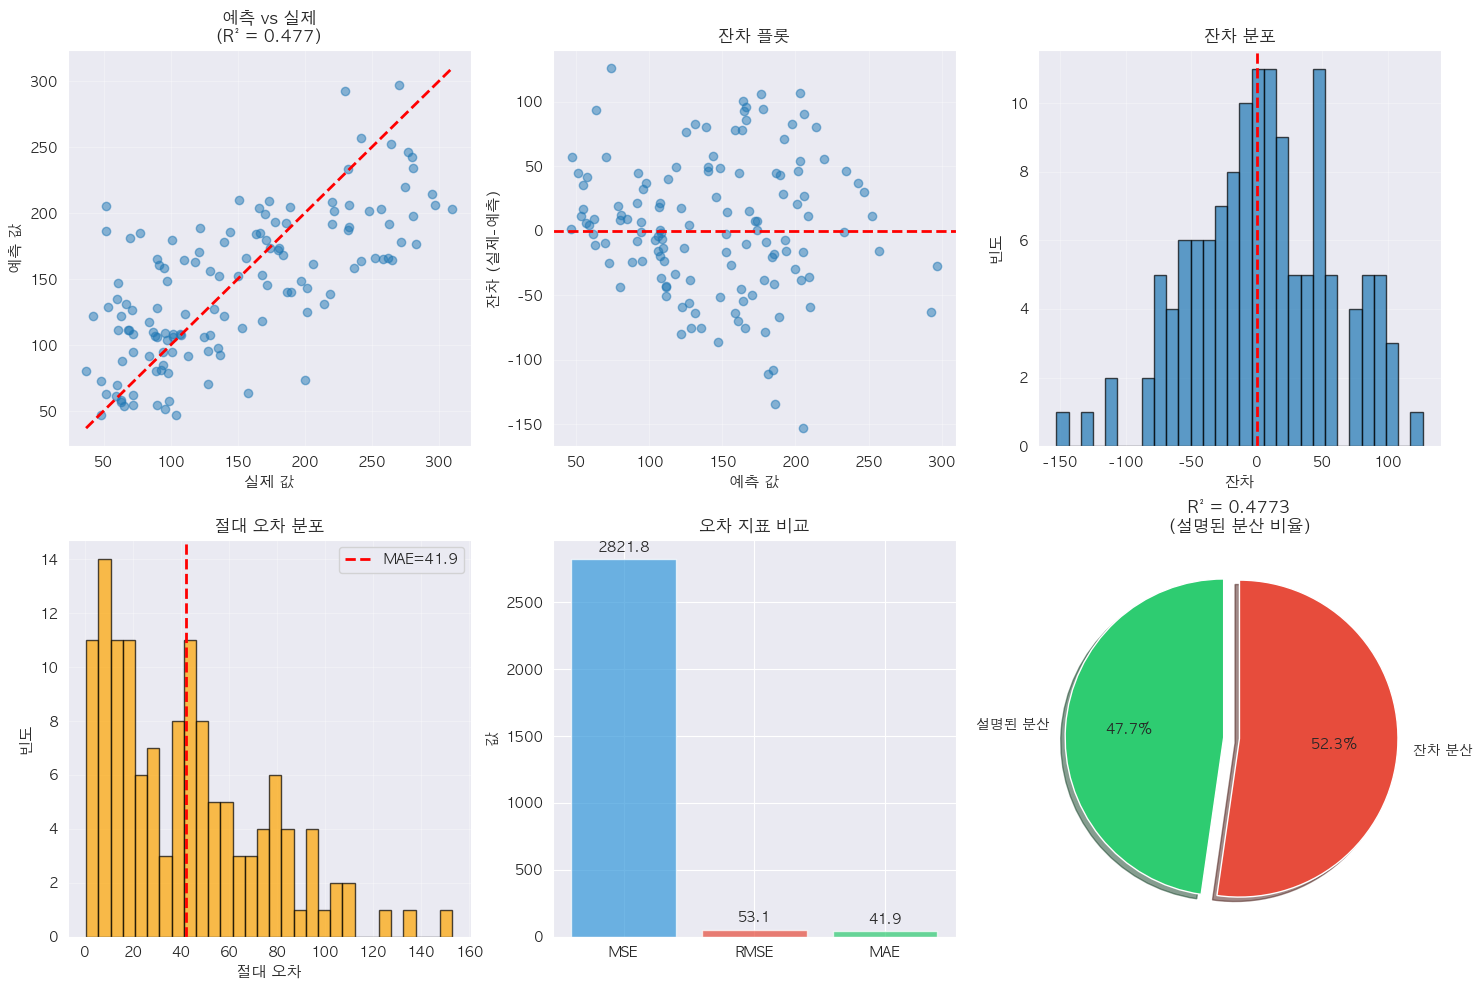

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 1. 예측 vs 실제 산점도
ax1 = axes[0, 0]
ax1.scatter(y_test_r, y_pred_r, alpha=0.5)
ax1.plot(
    [y_test_r.min(), y_test_r.max()], [y_test_r.min(), y_test_r.max()], "r--", lw=2
)
ax1.set_xlabel("실제 값", fontsize=11)
ax1.set_ylabel("예측 값", fontsize=11)
ax1.set_title(f"예측 vs 실제\n(R² = {r2:.3f})", fontsize=12, fontweight="bold")
ax1.grid(alpha=0.3)

# 2. 잔차 플롯
ax2 = axes[0, 1]
ax2.scatter(y_pred_r, errors, alpha=0.5)
ax2.axhline(y=0, color="r", linestyle="--", lw=2)
ax2.set_xlabel("예측 값", fontsize=11)
ax2.set_ylabel("잔차 (실제-예측)", fontsize=11)
ax2.set_title("잔차 플롯", fontsize=12, fontweight="bold")
ax2.grid(alpha=0.3)

# 3. 잔차 히스토그램
ax3 = axes[0, 2]
ax3.hist(errors, bins=30, edgecolor="black", alpha=0.7)
ax3.axvline(x=0, color="r", linestyle="--", lw=2)
ax3.set_xlabel("잔차", fontsize=11)
ax3.set_ylabel("빈도", fontsize=11)
ax3.set_title("잔차 분포", fontsize=12, fontweight="bold")
ax3.grid(alpha=0.3)

# 4. 절대 오차 분포
ax4 = axes[1, 0]
ax4.hist(abs_errors, bins=30, edgecolor="black", alpha=0.7, color="orange")
ax4.axvline(x=mae, color="r", linestyle="--", lw=2, label=f"MAE={mae:.1f}")
ax4.set_xlabel("절대 오차", fontsize=11)
ax4.set_ylabel("빈도", fontsize=11)
ax4.set_title("절대 오차 분포", fontsize=12, fontweight="bold")
ax4.legend()
ax4.grid(alpha=0.3)

# 5. 지표 비교 바차트
ax5 = axes[1, 1]
metrics_names = ["MSE", "RMSE", "MAE"]
metrics_values = [mse, rmse, mae]
bars = ax5.bar(
    metrics_names, metrics_values, color=["#3498db", "#e74c3c", "#2ecc71"], alpha=0.7
)
ax5.set_ylabel("값", fontsize=11)
ax5.set_title("오차 지표 비교", fontsize=12, fontweight="bold")
for bar, val in zip(bars, metrics_values):
    ax5.text(
        bar.get_x() + bar.get_width() / 2,
        val + max(metrics_values) * 0.02,
        f"{val:.1f}",
        ha="center",
        fontsize=10,
        fontweight="bold",
    )

# 6. R² 시각화
ax6 = axes[1, 2]
ss_res = np.sum(squared_errors)
ss_tot = np.sum((y_test_r - np.mean(y_test_r)) ** 2)
explained_var = ss_tot - ss_res

labels = ["설명된 분산", "잔차 분산"]
sizes = [explained_var, ss_res]
colors = ["#2ecc71", "#e74c3c"]
explode = (0.1, 0)
ax6.pie(
    sizes,
    explode=explode,
    labels=labels,
    colors=colors,
    autopct="%1.1f%%",
    shadow=True,
    startangle=90,
)
ax6.set_title(f"R² = {r2:.4f}\n(설명된 분산 비율)", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

In [7]:
# ### 2.4 다양한 모델 비교

print("\n🔄 여러 회귀 모델 성능 비교")
print("=" * 80)

# Random Forest 모델 추가
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_train_r, y_train_r)
y_pred_rf = rf_reg.predict(X_test_r)

# 결과 비교 테이블
results = pd.DataFrame(
    {
        "모델": ["Linear Regression", "Random Forest"],
        "MAE": [
            mean_absolute_error(y_test_r, y_pred_r),
            mean_absolute_error(y_test_r, y_pred_rf),
        ],
        "RMSE": [
            np.sqrt(mean_squared_error(y_test_r, y_pred_r)),
            np.sqrt(mean_squared_error(y_test_r, y_pred_rf)),
        ],
        "R²": [r2_score(y_test_r, y_pred_r), r2_score(y_test_r, y_pred_rf)],
    }
)

print(results.to_string(index=False))
print("=" * 80)


🔄 여러 회귀 모델 성능 비교
               모델       MAE      RMSE       R²
Linear Regression 41.919378 53.120156 0.477290
    Random Forest 42.750752 53.475620 0.470271


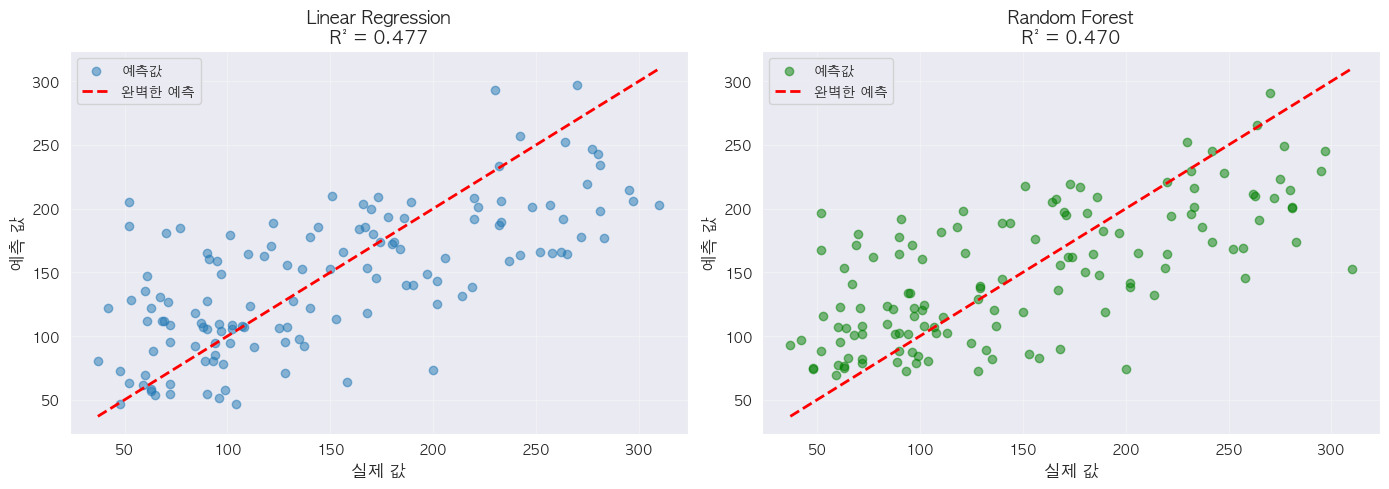

In [8]:
# 시각적 비교
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Linear Regression
axes[0].scatter(y_test_r, y_pred_r, alpha=0.5, label="예측값")
axes[0].plot(
    [y_test_r.min(), y_test_r.max()],
    [y_test_r.min(), y_test_r.max()],
    "r--",
    lw=2,
    label="완벽한 예측",
)
axes[0].set_xlabel("실제 값", fontsize=12)
axes[0].set_ylabel("예측 값", fontsize=12)
axes[0].set_title(
    f"Linear Regression\nR² = {r2_score(y_test_r, y_pred_r):.3f}",
    fontsize=13,
    fontweight="bold",
)
axes[0].legend()
axes[0].grid(alpha=0.3)

# Random Forest
axes[1].scatter(y_test_r, y_pred_rf, alpha=0.5, color="green", label="예측값")
axes[1].plot(
    [y_test_r.min(), y_test_r.max()],
    [y_test_r.min(), y_test_r.max()],
    "r--",
    lw=2,
    label="완벽한 예측",
)
axes[1].set_xlabel("실제 값", fontsize=12)
axes[1].set_ylabel("예측 값", fontsize=12)
axes[1].set_title(
    f"Random Forest\nR² = {r2_score(y_test_r, y_pred_rf):.3f}",
    fontsize=13,
    fontweight="bold",
)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [9]:
# ## 📚 Part 3: 종합 정리 및 실전 팁

print("\n" + "=" * 80)
print("📚 평가 지표 선택 가이드")
print("=" * 80)

summary = """
🎯 분류 모델 평가 지표 선택:

1. Accuracy (정확도)
   ✓ 언제: 클래스가 균형잡혀 있을 때
   ✗ 주의: 불균형 데이터에서는 부적절

2. Precision (정밀도)
   ✓ 언제: False Positive 비용이 클 때
   📌 예시: 스팸 필터 (정상 메일이 스팸으로 가면 안됨)

3. Recall (재현율)
   ✓ 언제: False Negative 비용이 클 때
   📌 예시: 암 진단 (암 환자를 놓치면 안됨)

4. F1-Score
   ✓ 언제: Precision과 Recall의 균형이 필요할 때
   ✓ 불균형 데이터에서 유용

5. ROC-AUC
   ✓ 언제: 전반적인 분류 성능 평가
   ✓ 임계값 독립적 평가
   ✗ 주의: 심한 불균형 데이터에서는 PR 곡선이 더 좋음

6. PR 곡선
   ✓ 언제: 클래스 불균형이 심할 때
   ✓ 양성 클래스에 집중할 때

---

📊 회귀 모델 평가 지표 선택:

1. MAE (Mean Absolute Error)
   ✓ 언제: 이상치에 덜 민감하게 평가
   ✓ 직관적 해석 필요

2. RMSE (Root Mean Squared Error)
   ✓ 언제: 큰 오차에 더 큰 페널티
   ✓ 타겟과 같은 스케일

3. MAPE (Mean Absolute Percentage Error)
   ✓ 언제: 상대적 오차가 중요할 때
   ✗ 주의: 0에 가까운 값이 있으면 불안정

4. R² (결정계수)
   ✓ 언제: 모델의 설명력 평가
   ✓ 스케일에 무관한 비교
   ✗ 주의: 음수 가능 (모델이 평균보다 나쁠 때)

---

💡 실전 팁:
• 여러 지표를 함께 사용하여 종합적으로 평가
• 비즈니스 목적에 맞는 지표 선택
• 교차 검증과 함께 사용
• 학습 데이터와 테스트 데이터 모두에서 평가
"""

print(summary)
print("=" * 80)


📚 평가 지표 선택 가이드

🎯 분류 모델 평가 지표 선택:

1. Accuracy (정확도)
   ✓ 언제: 클래스가 균형잡혀 있을 때
   ✗ 주의: 불균형 데이터에서는 부적절

2. Precision (정밀도)
   ✓ 언제: False Positive 비용이 클 때
   📌 예시: 스팸 필터 (정상 메일이 스팸으로 가면 안됨)

3. Recall (재현율)
   ✓ 언제: False Negative 비용이 클 때
   📌 예시: 암 진단 (암 환자를 놓치면 안됨)

4. F1-Score
   ✓ 언제: Precision과 Recall의 균형이 필요할 때
   ✓ 불균형 데이터에서 유용

5. ROC-AUC
   ✓ 언제: 전반적인 분류 성능 평가
   ✓ 임계값 독립적 평가
   ✗ 주의: 심한 불균형 데이터에서는 PR 곡선이 더 좋음

6. PR 곡선
   ✓ 언제: 클래스 불균형이 심할 때
   ✓ 양성 클래스에 집중할 때

---

📊 회귀 모델 평가 지표 선택:

1. MAE (Mean Absolute Error)
   ✓ 언제: 이상치에 덜 민감하게 평가
   ✓ 직관적 해석 필요

2. RMSE (Root Mean Squared Error)
   ✓ 언제: 큰 오차에 더 큰 페널티
   ✓ 타겟과 같은 스케일

3. MAPE (Mean Absolute Percentage Error)
   ✓ 언제: 상대적 오차가 중요할 때
   ✗ 주의: 0에 가까운 값이 있으면 불안정

4. R² (결정계수)
   ✓ 언제: 모델의 설명력 평가
   ✓ 스케일에 무관한 비교
   ✗ 주의: 음수 가능 (모델이 평균보다 나쁠 때)

---

💡 실전 팁:
• 여러 지표를 함께 사용하여 종합적으로 평가
• 비즈니스 목적에 맞는 지표 선택
• 교차 검증과 함께 사용
• 학습 데이터와 테스트 데이터 모두에서 평가

